### [ 히스토그램과 정규화 ] <hr>
- 데이터 수집 후 데이터 분포 확인은 1번째 작업
- 이미지 픽셀의 분포을 확인
    * 이진화 시에 임계값 선정시에 확인

- 정규화
    * 기준이 다른 데이터들의 기준을 맞추는 작업
    * 어느 한쪽에 집중되어 있는 픽셀을 고르게 펴주는 작업

In [90]:
import numpy as np, cv2, matplotlib.pyplot as plt, koreanize_matplotlib, sys
sys.path.append(r'C:\Users\Win11Pro\Desktop\KDT-14\[7]_CVISION')
from cv_utils import printPlotImage

In [91]:
IMG_FILE = '../Data/images/mountain.jpg'

In [92]:
# 이미지 데이터 로딩 및 기본 정보 확인
img = cv2.imread(IMG_FILE)
gray_img = cv2.imread(IMG_FILE, cv2.IMREAD_GRAYSCALE)
print(f'[기본정보] shape : {img.shape}, ndim : {img.ndim}, dtype : {img.dtype}')
print(f'[기본정보] shape : {gray_img.shape}, ndim : {gray_img.ndim}, dtype : {gray_img.dtype}')

[기본정보] shape : (450, 600, 3), ndim : 3, dtype : uint8
[기본정보] shape : (450, 600), ndim : 2, dtype : uint8


[기본정보] shape : (256, 1), ndim : 2, dtype : float32


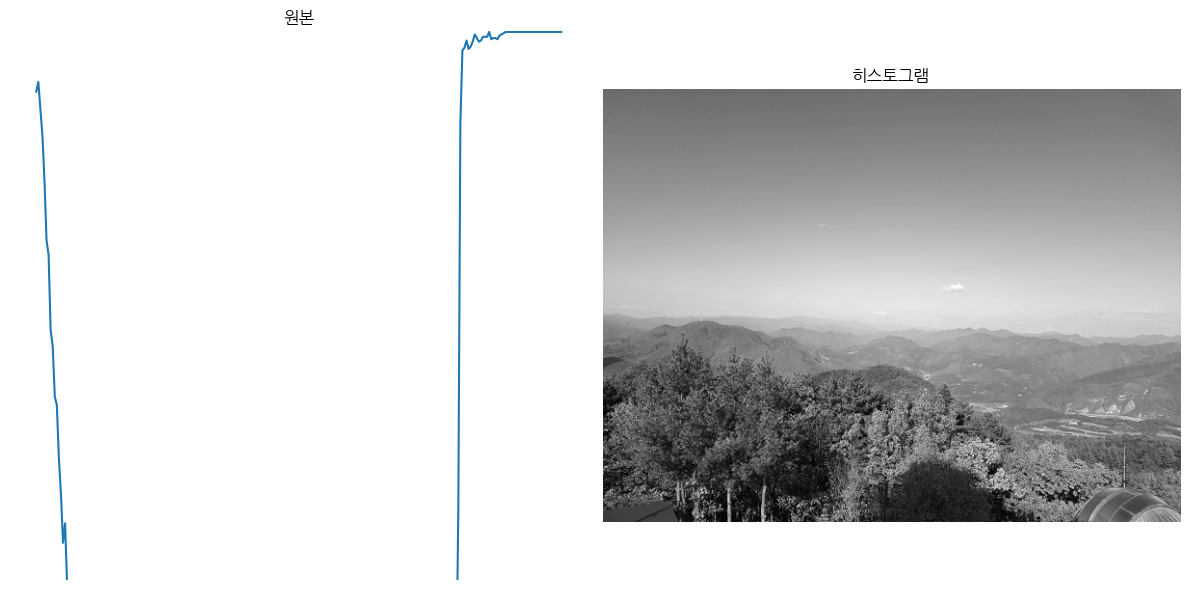

In [93]:
# cv2.calcHist()
# - 이미지 객체, 채널 수, 막대 수, => List
# - 값의 범위 => []
grayHist = cv2.calcHist([gray_img], [0], None, [256], [0,256])
print(f'[기본정보] shape : {grayHist.shape}, ndim : {grayHist.ndim}, dtype : {grayHist.dtype}')

# 시각화 : 원본이미지, 픽셀분포
titles_ = ['원본', '히스토그램']
plots_, images_ = [grayHist], [gray_img]
cmap_ = ['gray']

printPlotImage(1,2, titles_, plots_, images_, cmap_)

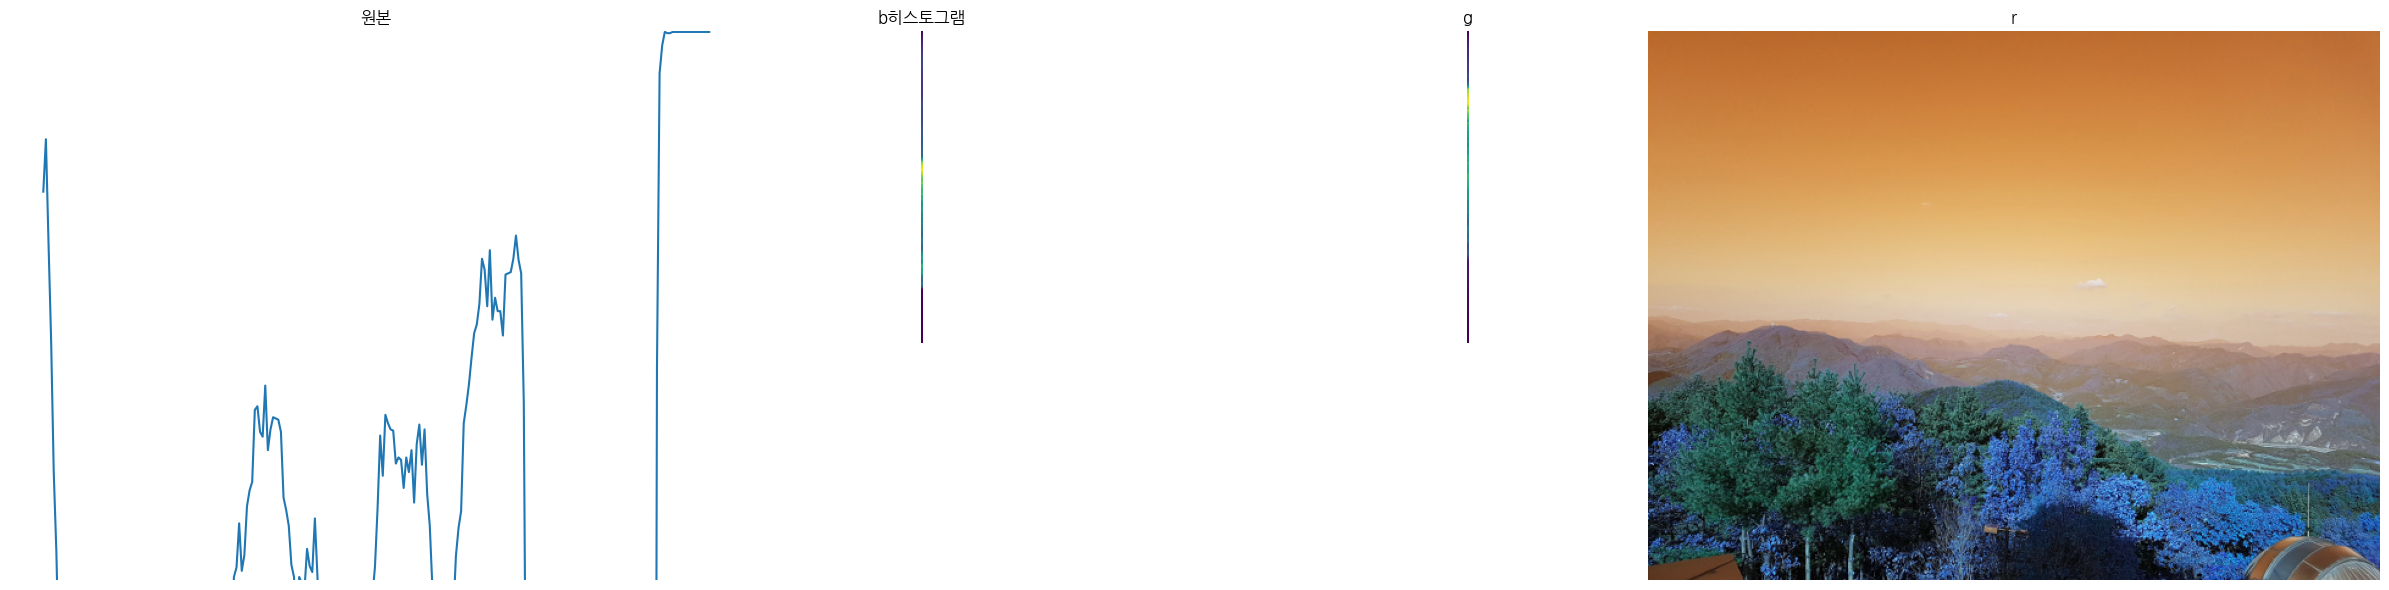

In [94]:
b, g, r = cv2.split(img)
rgbhist = cv2.calcHist([r,g,b], [0,1,2], None, [256, 256, 256], [0, 256, 0, 256, 0, 256])

bhist = cv2.calcHist([b], [0], None, [256], [0, 256])
ghist = cv2.calcHist([g], [0], None, [256], [0, 256])
rhist = cv2.calcHist([r], [0], None, [256], [0, 256])

# 시각화 : 원본이미지, 픽셀분포(bgr)
titles_ = ['원본', 'b히스토그램', "g", 'r']
plots_, images_ = [bhist, ghist, rhist], [img]
cmap_ = [None]

printPlotImage(1,4, titles_, plots_, images_, cmap_)

### [ 정규화 ] <hr>

In [95]:
IMG_FILE = '../Data/images/abnormal.jpg'

In [96]:
mount = cv2.imread(IMG_FILE, cv2.IMREAD_GRAYSCALE)
print(f'[기본정보] shape : {mount.shape}, ndim : {mount.ndim}')

[기본정보] shape : (360, 480), ndim : 2


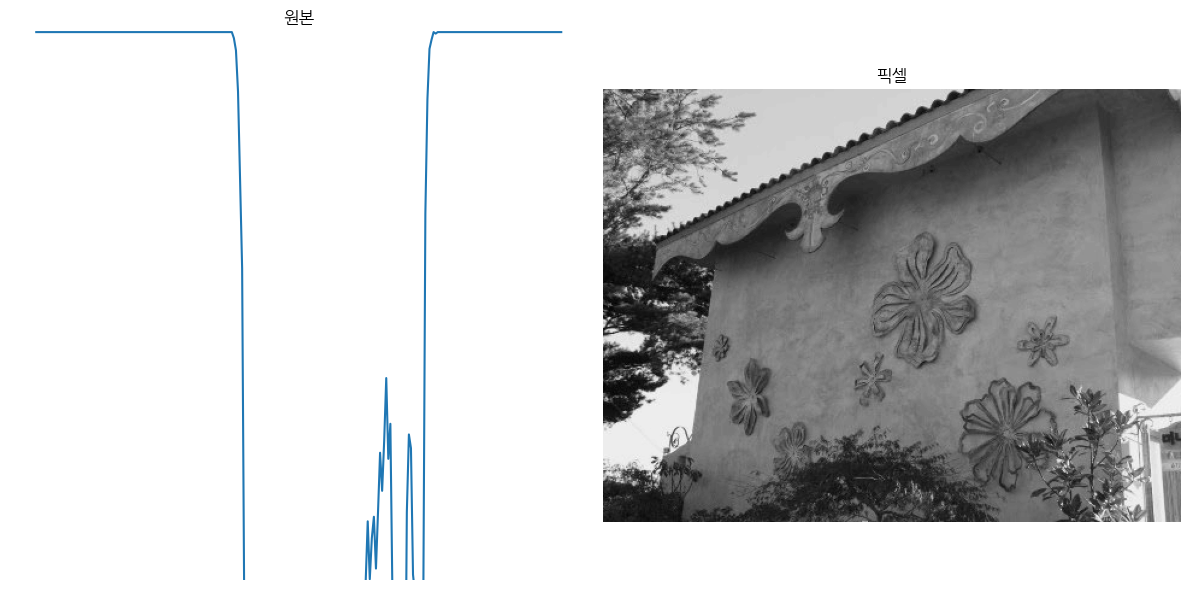

In [97]:
mountHist = cv2.calcHist([mount], [0], None, [256], [0,256])

printPlotImage(1,2, ['원본', '픽셀'], [mountHist], [mount], ['gray'])